# 项目：用逻辑回归预测泰坦尼克号幸存情况

## 分析目标

此数据分析报告的目的是，基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。

## 简介

> 泰坦尼克号（英语：RMS Titanic）是一艘奥林匹克级邮轮，于1912年4月首航时撞上冰山后沉没。泰坦尼克号是同级的3艘超级邮轮中的第2艘，与姐妹船奥林匹克号和不列颠号为白星航运公司的乘客们提供大西洋旅行。

> 泰坦尼克号由位于北爱尔兰贝尔法斯特的哈兰·沃尔夫船厂兴建，是当时最大的客运轮船，由于其规模相当一艘现代航空母舰，因而号称“上帝也沉没不了的巨型邮轮”。在泰坦尼克号的首航中，从英国南安普敦出发，途经法国瑟堡-奥克特维尔以及爱尔兰昆士敦，计划横渡大西洋前往美国纽约市。但因为人为错误，于1912年4月14日船上时间夜里11点40分撞上冰山；2小时40分钟后，即4月15日凌晨02点20分，船裂成两半后沉入大西洋，死亡人数超越1500人，堪称20世纪最大的海难事件，同时也是最广为人知的海难之一。

数据集包括两个数据表：`titianic_train.csv`和`titanic_test.csv`。

`titianic_train.csv`记录了超过八百位泰坦尼克号乘客在沉船事件后的幸存情况，以及乘客的相关信息，包括所在船舱等级、性别、年龄、同乘伴侣/同胞数量、同乘父母/孩子数量，等等。

`titanic_test.csv`只包含乘客（这些乘客不在`titianic_train.csv`里）相关信息，此文件可以被用于预测乘客是否幸存。

`titianic_train.csv`每列的含义如下：
- PassengerId：乘客ID
- survival：是否幸存
   - 0	否
   - 1	是
- pclass：船舱等级
   - 1	一等舱
   - 2	二等舱
   - 3  三等舱
- sex：性别
- Age：年龄
- sibsp：同乘伴侣/同胞数量
- parch：同乘父母/孩子数量
- ticket：船票号
- fare：票价金额
- cabin：船舱号
- embarked：登船港口
   - C  瑟堡
   - Q  皇后镇
   - S  南安普敦
   
   
`titianic_test.csv`每列的含义和上面相同，但不具备survival变量的数据，即是否幸存。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
import matplotlib
matplotlib.rc("font",family=' Microsoft YaHei')

In [3]:
data=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\titanic_train.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
data=data.dropna(subset=["Age"])
data.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,448.582633,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,259.119524,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.250000,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,677.750000,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [6]:
data["PassengerId"].duplicated().sum()

np.int64(0)

In [7]:
data["Survived"].value_counts()

Survived
0    424
1    290
Name: count, dtype: int64

In [8]:
Pclass1=data["Pclass"].value_counts()
Pclass1

Pclass
3    355
1    186
2    173
Name: count, dtype: int64

In [9]:
Sex1=data["Sex"].value_counts()
Sex1

Sex
male      453
female    261
Name: count, dtype: int64

In [10]:
data["Cabin"].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
F2             3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 134, dtype: int64

In [11]:
data["Embarked"]=data["Embarked"].fillna("S")
Embarked1=data["Embarked"].value_counts()
print(Embarked1)
data.info()

Embarked
S    556
C    130
Q     28
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     714 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


In [12]:
data["Age"].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [13]:
SibSp1=data["SibSp"].value_counts()
SibSp1

SibSp
0    471
1    183
2     25
4     18
3     12
5      5
Name: count, dtype: int64

In [14]:
Parch1=data["Parch"].value_counts()
Parch1

Parch
0    521
1    110
2     68
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Fare
13.0000    41
26.0000    30
8.0500     29
10.5000    24
7.8958     23
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 220, dtype: int64


<Axes: xlabel='Fare', ylabel='Density'>

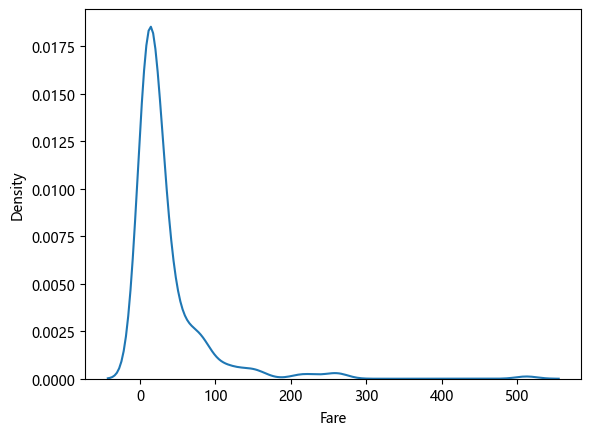

In [15]:
Fare1=data["Fare"].value_counts()
print(Fare1)
sns.kdeplot(data["Fare"])

   Pclass     Sex  Survived
0       1  female  0.964706
1       1    male  0.396040
2       2  female  0.918919
3       2    male  0.151515
4       3  female  0.460784
5       3    male  0.150198


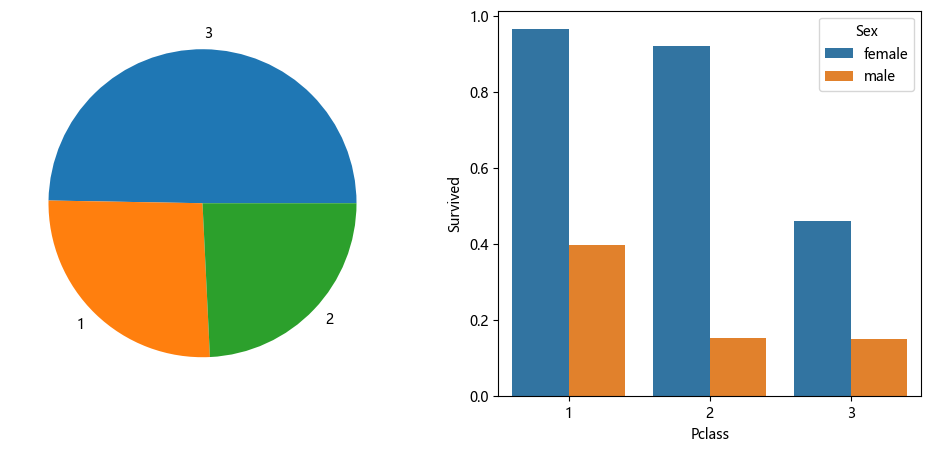

In [16]:
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Pclass1,labels=Pclass1.index)
Pclass2=data.groupby(["Pclass","Sex"])["Survived"].mean()
Pclass2=Pclass2.reset_index()
sns.barplot(Pclass2,x="Pclass",y="Survived",hue="Sex",ax=axes[1])
print(Pclass2)

Sex
female    0.754789
male      0.205298
Name: Survived, dtype: float64


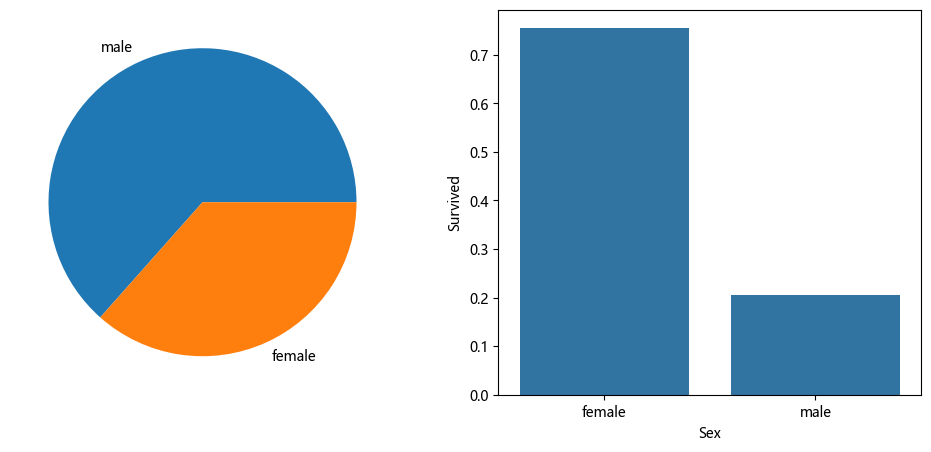

In [17]:
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Sex1,labels=Sex1.index)
Sex2=data.groupby("Sex")["Survived"].mean()
sns.barplot(x=Sex2.index,y=Sex2,ax=axes[1])
print(Sex2)

Age
未成年    0.503597
成年人    0.388788
老年人    0.227273
Name: Survived, dtype: float64


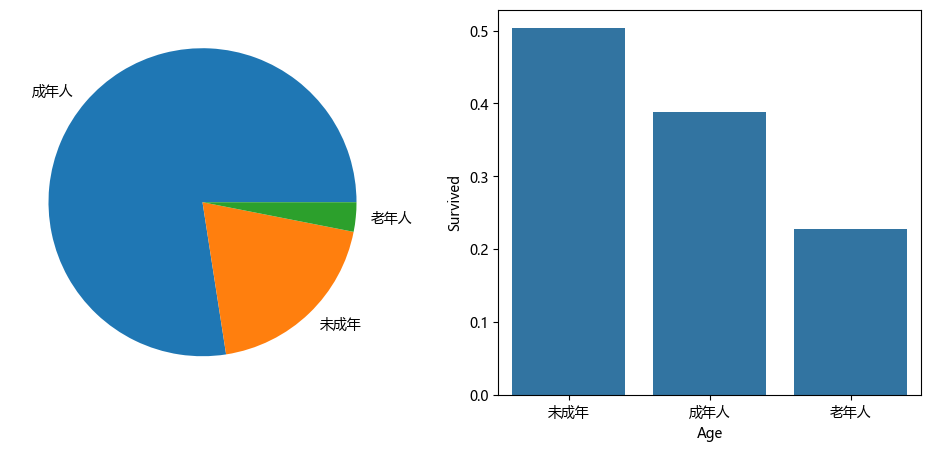

In [18]:
years=[0,18,60,100]
years_name=["未成年","成年人","老年人"]
people_old=pd.cut(data["Age"],years,labels=years_name).value_counts()
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(people_old,labels=people_old.index)
data1=data.copy()
data1["Age"]=pd.cut(data["Age"],years,labels=years_name)
Age2=data1.groupby("Age")["Survived"].mean()
sns.barplot(x=Age2.index,y=Age2,ax=axes[1])
print(Age2)

SibSp
0    0.371550
1    0.530055
2    0.440000
3    0.333333
4    0.166667
5    0.000000
Name: Survived, dtype: float64


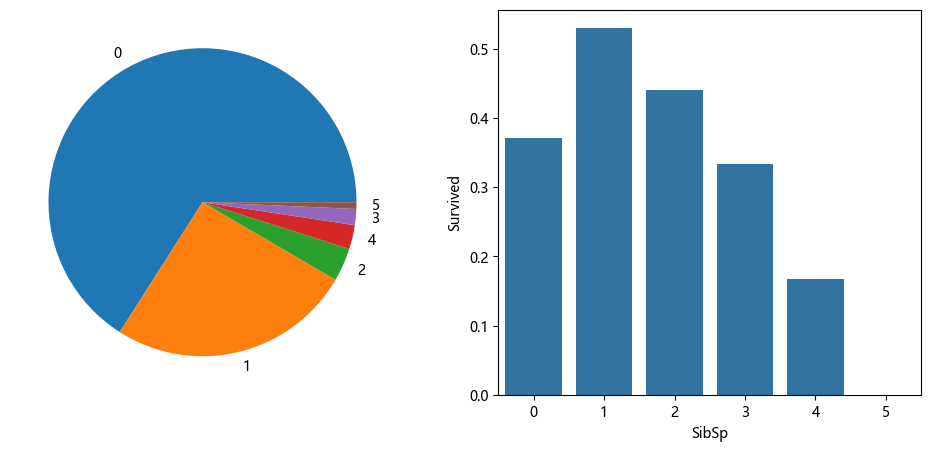

In [19]:
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(SibSp1,labels=SibSp1.index)
SibSp2=data.groupby("SibSp")["Survived"].mean()
sns.barplot(x=SibSp2.index,y=SibSp2,ax=axes[1])
print(SibSp2)

Parch
0    0.357006
1    0.554545
2    0.573529
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


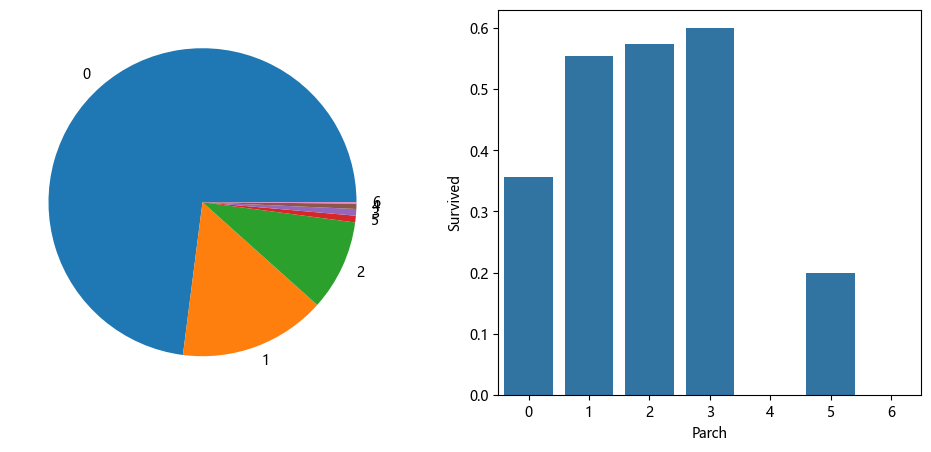

In [20]:
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Parch1,labels=Parch1.index)
Parch2=data.groupby("Parch")["Survived"].mean()
sns.barplot(x=Parch2.index,y=Parch2,ax=axes[1])
print(Parch2)

Fare
小资    0.207792
中产    0.306878
小富    0.488235
巨富    0.597938
Name: Survived, dtype: float64


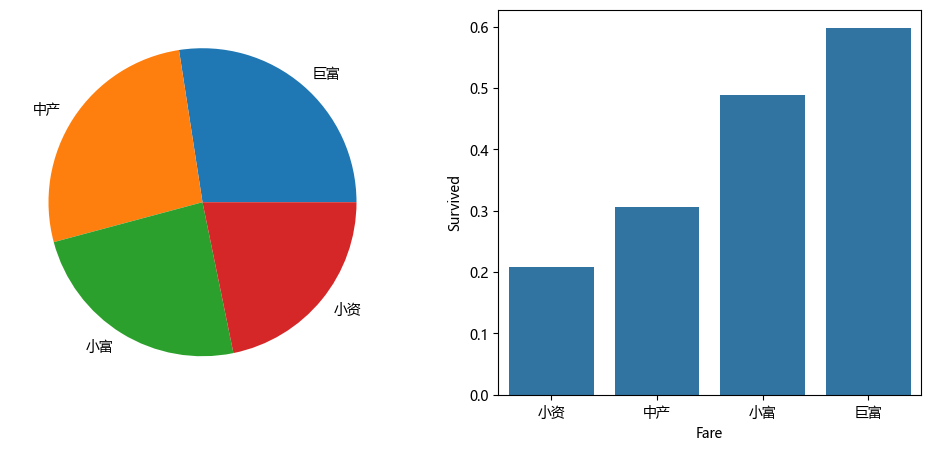

In [21]:
Fare=[0,8,15,31,600]
Fare_name=["小资","中产","小富","巨富"]
people_Fare=pd.cut(data["Fare"],Fare,labels=Fare_name).value_counts()
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(people_Fare,labels=people_Fare.index)
data2=data.copy()
data2["Fare"]=pd.cut(data["Fare"],Fare,labels=Fare_name)
Fare2=data2.groupby("Fare")["Survived"].mean()
sns.barplot(x=Fare2.index,y=Fare2,ax=axes[1])
print(Fare2)

Embarked
C    0.607692
Q    0.285714
S    0.365108
Name: Survived, dtype: float64


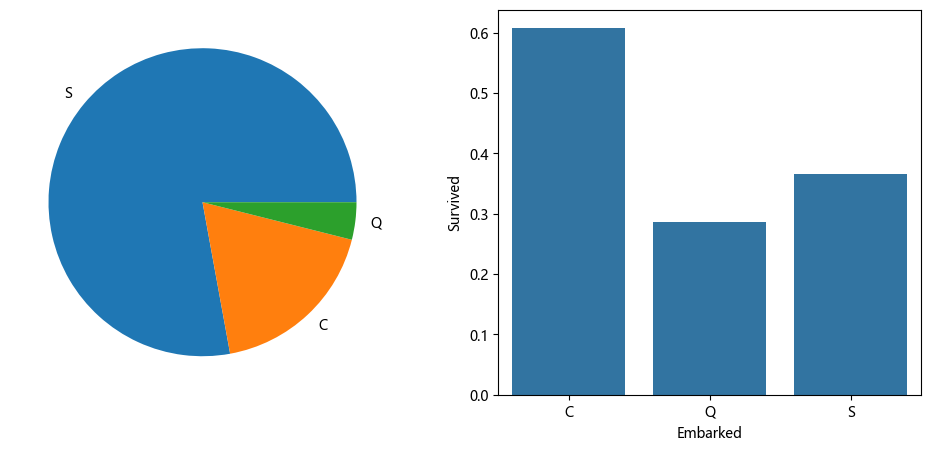

In [22]:
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Embarked1,labels=Embarked1.index)
Embarked2=data.groupby("Embarked")["Survived"].mean()
sns.barplot(x=Embarked2.index,y=Embarked2,ax=axes[1])
print(Embarked2)

In [23]:
data.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     714 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


In [24]:
new_data=data.drop(["PassengerId","Name","Ticket","Cabin"],axis=1)
new_data.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Pclass    714 non-null    int64  
 2   Sex       714 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     714 non-null    int64  
 5   Parch     714 non-null    int64  
 6   Fare      714 non-null    float64
 7   Embarked  714 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 50.2 KB


In [25]:
new_data1=pd.get_dummies(new_data,columns=["Pclass","Sex","Embarked"],dtype=int,drop_first=True)

                 Age     SibSp     Parch      Fare  Pclass_2  Pclass_3  \
Age         1.000000  0.308247  0.189119  0.096067  0.006954  0.312271   
SibSp       0.308247  1.000000  0.383820  0.138329  0.051647  0.078461   
Parch       0.189119  0.383820  1.000000  0.205119  0.017739  0.029115   
Fare        0.096067  0.138329  0.205119  1.000000  0.141399  0.403639   
Pclass_2    0.006954  0.051647  0.017739  0.141399  1.000000  0.562330   
Pclass_3    0.312271  0.078461  0.029115  0.403639  0.562330  1.000000   
Sex_male    0.093254  0.103950  0.246972  0.184994  0.073036  0.161520   
Embarked_Q  0.022405  0.051619  0.009126  0.062765  0.080567  0.145442   
Embarked_S  0.023233  0.018126  0.012491  0.249353  0.167588  0.091485   

            Sex_male  Embarked_Q  Embarked_S  
Age         0.093254    0.022405    0.023233  
SibSp       0.103950    0.051619    0.018126  
Parch       0.246972    0.009126    0.012491  
Fare        0.184994    0.062765    0.249353  
Pclass_2    0.073036    

<Axes: >

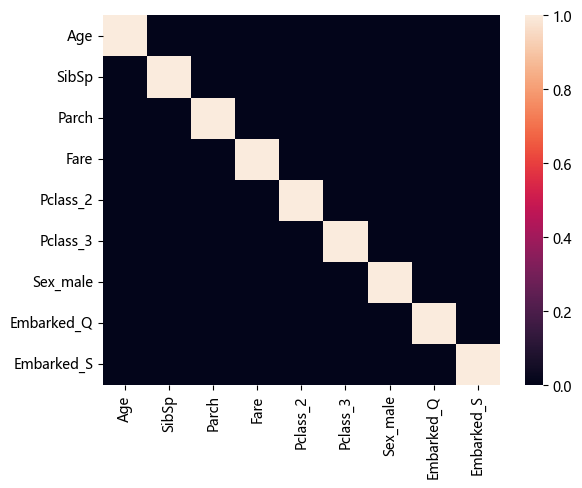

In [26]:
y=new_data1["Survived"]
x=new_data1.drop("Survived",axis=1)
print(x.corr().abs())
sns.heatmap(x.corr().abs()>0.8)

In [27]:
x=sm.add_constant(x)
x

,const,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,1.0,22.0,1,0,7.2500,0,1,1,0,1
1,1.0,38.0,1,0,71.2833,0,0,0,0,0
2,1.0,26.0,0,0,7.9250,0,1,0,0,1
3,1.0,35.0,1,0,53.1000,0,0,0,0,1
4,1.0,35.0,0,0,8.0500,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...
885,1.0,39.0,0,5,29.1250,0,1,0,1,0
886,1.0,27.0,0,0,13.0000,1,0,1,0,1
887,1.0,19.0,0,0,30.0000,0,0,0,0,1
889,1.0,26.0,0,0,30.0000,0,0,1,0,0


In [28]:
result=sm.Logit(y,x).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.443215
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      704
Method:                           MLE   Df Model:                            9
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                  0.3438
Time:                        20:45:45   Log-Likelihood:                -316.46
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 5.069e-66
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4379      0.536      8.278      0.000       3.387       5.489
Age           -0.0431      0.008     -5.190      0.000      -0.059      -0.027
SibSp         -0.3647      0.129     -2.817      0.005      -0.618      -0.111
Parch         -0.0625      0.124     -0.504      0.614      -0.305       0.180
Fare           0.0015      0.003      0.570      0.568      -0.004       0.007
Pclass_2      -1.1991      0.329     -3.644      0.000      -1.844      -0.554
Pclass_3      -2.4031      0.343     -6.998      0.000      -3.076      -1.730
Sex_male      -2.6483      0.223    -11.893      0.000      -3.085      -2.212
Embarked_Q    -0.8218      0.601     -1.368      0.171      -2.000       0.356
Embarked_S    -0.3957      0.275     -1.441      0.149      -0.934       0.142
==============================================================================
"""

               Age     SibSp  Pclass_2  Pclass_3  Sex_male
Age       1.000000  0.308247  0.006954  0.312271  0.093254
SibSp     0.308247  1.000000  0.051647  0.078461  0.103950
Pclass_2  0.006954  0.051647  1.000000  0.562330  0.073036
Pclass_3  0.312271  0.078461  0.562330  1.000000  0.161520
Sex_male  0.093254  0.103950  0.073036  0.161520  1.000000


<Axes: >

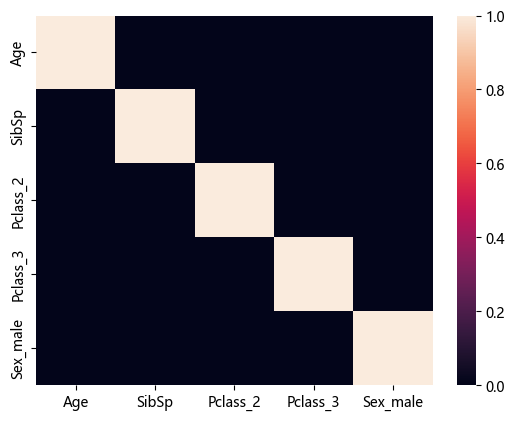

In [29]:
y=new_data1["Survived"]
x=new_data1.drop(["Survived","Parch","Fare","Embarked_Q","Embarked_S"],axis=1)
print(x.corr().abs())
sns.heatmap(x.corr().abs()>0.8)

In [30]:
x=sm.add_constant(x)
x

,const,Age,SibSp,Pclass_2,Pclass_3,Sex_male
0,1.0,22.0,1,0,1,1
1,1.0,38.0,1,0,0,0
2,1.0,26.0,0,0,1,0
3,1.0,35.0,1,0,0,0
4,1.0,35.0,0,0,1,1
...,...,...,...,...,...,...
885,1.0,39.0,0,0,1,0
886,1.0,27.0,0,1,0,1
887,1.0,19.0,0,0,0,0
889,1.0,26.0,0,0,0,1


In [31]:
result=sm.Logit(y,x).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.445774
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      708
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                  0.3400
Time:                        20:45:46   Log-Likelihood:                -318.28
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 9.745e-69
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3342      0.451      9.617      0.000       3.451       5.218
Age           -0.0448      0.008     -5.442      0.000      -0.061      -0.029
SibSp         -0.3802      0.122     -3.129      0.002      -0.618      -0.142
Pclass_2      -1.4144      0.285     -4.967      0.000      -1.972      -0.856
Pclass_3      -2.6526      0.286     -9.280      0.000      -3.213      -2.092
Sex_male      -2.6277      0.215    -12.235      0.000      -3.049      -2.207
==============================================================================
"""

In [32]:
new_observation=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\titanic_test.csv")
new_observation

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [33]:
x

,const,Age,SibSp,Pclass_2,Pclass_3,Sex_male
0,1.0,22.0,1,0,1,1
1,1.0,38.0,1,0,0,0
2,1.0,26.0,0,0,1,0
3,1.0,35.0,1,0,0,0
4,1.0,35.0,0,0,1,1
...,...,...,...,...,...,...
885,1.0,39.0,0,0,1,0
886,1.0,27.0,0,1,0,1
887,1.0,19.0,0,0,0,0
889,1.0,26.0,0,0,0,1


In [34]:
new_observation=new_observation.drop(["PassengerId","Name","Parch","Ticket","Fare","Cabin","Embarked"],axis=1)
new_observation

,Pclass,Sex,Age,SibSp
0,3,male,34.5,0
1,3,female,47.0,1
2,2,male,62.0,0
3,3,male,27.0,0
4,3,female,22.0,1
...,...,...,...,...
413,3,male,NaN,0
414,1,female,39.0,0
415,3,male,38.5,0
416,3,male,NaN,0


In [35]:
new_observation["Age"]=new_observation["Age"].fillna(30.272590)

In [36]:
new_observation.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  418 non-null    int64  
 1   Sex     418 non-null    str    
 2   Age     418 non-null    float64
 3   SibSp   418 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 13.2 KB


In [37]:
new_observation.describe()

,Pclass,Age,SibSp
count,418.000000,418.000000,418.000000
mean,2.265550,30.272590,0.447368
std,0.841838,12.634534,0.896760
min,1.000000,0.170000,0.000000
25%,1.000000,23.000000,0.000000
50%,3.000000,30.272590,0.000000
75%,3.000000,35.750000,1.000000
max,3.000000,76.000000,8.000000


In [38]:
new_observation["Pclass"]=pd.Categorical(new_observation["Pclass"],categories=[1,2,3])
new_observation["Sex"]=pd.Categorical(new_observation["Sex"],categories=["female","male"])
new_observation=pd.get_dummies(new_observation,columns=["Pclass","Sex"],dtype=int, drop_first = True)
new_observation

,Age,SibSp,Pclass_2,Pclass_3,Sex_male
0,34.50000,0,0,1,1
1,47.00000,1,0,1,0
2,62.00000,0,1,0,1
3,27.00000,0,0,1,1
4,22.00000,1,0,1,0
...,...,...,...,...,...
413,30.27259,0,0,1,1
414,39.00000,0,0,0,0
415,38.50000,0,0,1,1
416,30.27259,0,0,1,1


In [39]:
x

,const,Age,SibSp,Pclass_2,Pclass_3,Sex_male
0,1.0,22.0,1,0,1,1
1,1.0,38.0,1,0,0,0
2,1.0,26.0,0,0,1,0
3,1.0,35.0,1,0,0,0
4,1.0,35.0,0,0,1,1
...,...,...,...,...,...,...
885,1.0,39.0,0,0,1,0
886,1.0,27.0,0,1,0,1
887,1.0,19.0,0,0,0,0
889,1.0,26.0,0,0,0,1


In [40]:
new_observation=sm.add_constant(new_observation)
new_observation

,const,Age,SibSp,Pclass_2,Pclass_3,Sex_male
0,1.0,34.50000,0,0,1,1
1,1.0,47.00000,1,0,1,0
2,1.0,62.00000,0,1,0,1
3,1.0,27.00000,0,0,1,1
4,1.0,22.00000,1,0,1,0
...,...,...,...,...,...,...
413,1.0,30.27259,0,0,1,1
414,1.0,39.00000,0,0,0,0
415,1.0,38.50000,0,0,1,1
416,1.0,30.27259,0,0,1,1


In [41]:
result.predict(new_observation)

0      0.076541
1      0.309531
2      0.077063
3      0.103901
4      0.578515
         ...   
413    0.091033
414    0.930122
415    0.064807
416    0.091033
417    0.064087
Length: 418, dtype: float64

In [42]:
new_observation1=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\titanic_test.csv")
new_observation1["survived"]=result.predict(new_observation)
new_observation1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.076541
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.309531
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.077063
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.103901
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.578515
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0.091033
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.930122
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0.064807
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0.091033


In [45]:
new_observation1.head(50)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.076541
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.309531
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.077063
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.103901
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.578515
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,0.171827
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,0.583897
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,0.222392
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,0.705974
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,0.066209


   Pclass     Sex  survived
0       1  female  0.890292
1       1    male  0.454574
2       2  female  0.821957
3       2    male  0.245546
4       3  female  0.581284
5       3    male  0.099103


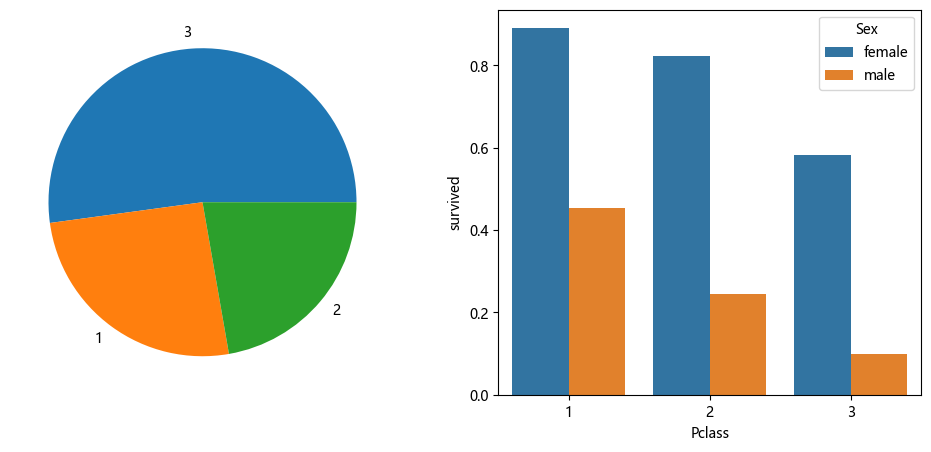

In [48]:
Pclass1=new_observation1["Pclass"].value_counts()
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Pclass1,labels=Pclass1.index)
Pclass2=new_observation1.groupby(["Pclass","Sex"])["survived"].mean()
Pclass2=Pclass2.reset_index()
sns.barplot(Pclass2,x="Pclass",y="survived",hue="Sex",ax=axes[1])
print(Pclass2)

Sex
female    0.730433
male      0.209959
Name: survived, dtype: float64


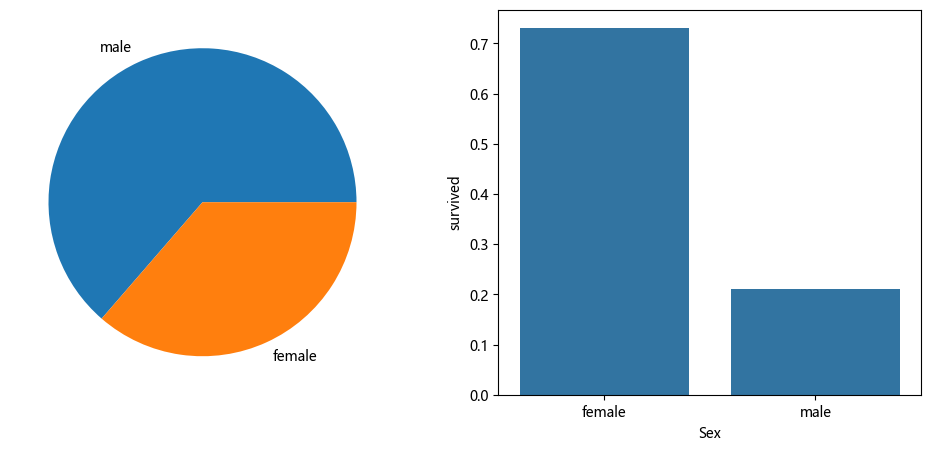

In [49]:
Sex1=new_observation1["Sex"].value_counts()
figure, axes = plt.subplots(1, 2,figsize=(12,5))
axes[0].pie(Sex1,labels=Sex1.index)
Sex2=new_observation1.groupby("Sex")["survived"].mean()
sns.barplot(x=Sex2.index,y=Sex2,ax=axes[1])
print(Sex2)

In [50]:
57/175

0.32571428571428573